In [39]:
from pathlib import Path

import numpy as np
import awkward as ak
import uproot
import vector
import h5py
import matplotlib.pyplot as plt

vector.register_awkward()

OTUS_PPZEE_FILE = Path("C:/Users/AhrixMarin/Desktop/otus/data/ppzee.hdf5")

CMS_EE_FILE = Path(
    "C:/Users/AhrixMarin/Desktop/otus/experiments/cms_zpeak/data/Run2012B_DoubleElectron.root"
)

CMS_MUMU_FILE = Path(
    "C:/Users/AhrixMarin/Desktop/otus/experiments/cms_zpeak/data/Run2012BC_DoubleMuParked_Muons.root"
)

# Output folders
FIG_DIR = Path("C:/Users/AhrixMarin/Desktop/otus/experiments/cms_zpeak/figures")

import sys

NOTEBOOK_DIR = Path.cwd().resolve()
OTUS_DIR = NOTEBOOK_DIR.parents[2]

if str(OTUS_DIR) not in sys.path:
    sys.path.insert(0, str(OTUS_DIR))

print("Notebook dir:", NOTEBOOK_DIR)
print("OTUS dir:", OTUS_DIR)

# Physics constants / common plotting setup
Z_MASS_GEV = 91.1880

MASS_MIN = 70.0
MASS_MAX = 110.0
N_BINS = 80
MASS_BINS = np.linspace(MASS_MIN, MASS_MAX, N_BINS + 1)
BIN_WIDTH = MASS_BINS[1] - MASS_BINS[0]

print("OTUS ppzee file:")
print(" ", OTUS_PPZEE_FILE.resolve())

print("\nCMS ee file:")
print(" ", CMS_EE_FILE.resolve())

print("\nCMS mumu file:")
print(" ", CMS_MUMU_FILE.resolve())

print("\nFigure output folder:")
print(" ", FIG_DIR.resolve())

Notebook dir: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\notebooks
OTUS dir: C:\Users\AhrixMarin\Desktop\otus
OTUS ppzee file:
  C:\Users\AhrixMarin\Desktop\otus\data\ppzee.hdf5

CMS ee file:
  C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012B_DoubleElectron.root

CMS mumu file:
  C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012BC_DoubleMuParked_Muons.root

Figure output folder:
  C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\figures


In [17]:
for path in [OTUS_PPZEE_FILE, CMS_EE_FILE, CMS_MUMU_FILE]:
    assert path.exists(), f"File not found: {path.resolve()}"

print("All input files found.")

All input files found.


## 1. CMS Open Data \(Z\to e^+e^-\) x-space peak

In [8]:
assert CMS_EE_FILE.exists(), f"File not found: {CMS_EE_FILE.resolve()}"

f_ee = uproot.open(CMS_EE_FILE)
events_ee = f_ee["Events"]

branches_ee = [
    "nElectron",
    "Electron_pt",
    "Electron_eta",
    "Electron_phi",
    "Electron_mass",
    "Electron_charge",
    "Electron_pfRelIso03_all",
    "Electron_dxy",
    "Electron_dxyErr",
    "Electron_dz",
    "Electron_dzErr",
]

arrays_ee = events_ee.arrays(branches_ee, library="ak")

print("File:", CMS_EE_FILE.resolve())
print("Number of events:", events_ee.num_entries)
print("Loaded events:", len(arrays_ee["nElectron"]))

File: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012B_DoubleElectron.root
Number of events: 21474287
Loaded events: 21474287


In [10]:
# Basic electron selection
electron_pt_min = 20.0
electron_abs_eta_max = 2.5

# Simple quality/isolation cuts
electron_iso_max = 0.15
electron_dxy_max = 0.05
electron_dz_max = 0.10

electrons = ak.zip(
    {
        "pt": arrays_ee["Electron_pt"],
        "eta": arrays_ee["Electron_eta"],
        "phi": arrays_ee["Electron_phi"],
        "mass": arrays_ee["Electron_mass"],
        "charge": arrays_ee["Electron_charge"],
        "pfRelIso03_all": arrays_ee["Electron_pfRelIso03_all"],
        "dxy": arrays_ee["Electron_dxy"],
        "dxyErr": arrays_ee["Electron_dxyErr"],
        "dz": arrays_ee["Electron_dz"],
        "dzErr": arrays_ee["Electron_dzErr"],
    },
    with_name="Momentum4D",
)

abs_eta_ee = np.abs(electrons.eta)

# ECAL barrel/endcap transition gap veto
outside_ecal_gap = ~((abs_eta_ee > 1.4442) & (abs_eta_ee < 1.566))

selected_electrons = electrons[
    (electrons.pt > electron_pt_min)
    & (abs_eta_ee < electron_abs_eta_max)
    & outside_ecal_gap
    & (electrons.pfRelIso03_all < electron_iso_max)
    & (np.abs(electrons.dxy) < electron_dxy_max)
    & (np.abs(electrons.dz) < electron_dz_max)
]

pairs_ee = ak.combinations(selected_electrons, 2, fields=["e1", "e2"])
os_pairs_ee = pairs_ee[(pairs_ee.e1.charge * pairs_ee.e2.charge) < 0]

m_ee_nested = (os_pairs_ee.e1 + os_pairs_ee.e2).mass
os_pairs_ee_z = os_pairs_ee[(m_ee_nested > 70) & (m_ee_nested < 110)]

masses_ee_z = ak.to_numpy(ak.flatten((os_pairs_ee_z.e1 + os_pairs_ee_z.e2).mass))

counts_ee, edges_ee = np.histogram(masses_ee_z, bins=MASS_BINS)
centers_ee = 0.5 * (edges_ee[:-1] + edges_ee[1:])
peak_ee = centers_ee[np.argmax(counts_ee)]

print("Total selected electrons:", ak.sum(ak.num(selected_electrons)))
print("Events with >=2 selected electrons:", ak.sum(ak.num(selected_electrons) >= 2))
print("Opposite-sign dielectron pairs:", ak.sum(ak.num(os_pairs_ee)))
print("Opposite-sign dielectron pairs in 70-110 GeV:", len(masses_ee_z))
print(f"Mean m_ee:   {np.mean(masses_ee_z):.4f} GeV")
print(f"Median m_ee: {np.median(masses_ee_z):.4f} GeV")
print(f"Peak bin center: {peak_ee:.2f} GeV")

Total selected electrons: 9734445
Events with >=2 selected electrons: 1903393
Opposite-sign dielectron pairs: 1639419
Opposite-sign dielectron pairs in 70-110 GeV: 1344681
Mean m_ee:   90.6381 GeV
Median m_ee: 91.1484 GeV
Peak bin center: 91.75 GeV


## 2. CMS Open Data \(Z\to \mu^+\mu^-\) x-space peak

In [11]:
assert CMS_MUMU_FILE.exists(), f"File not found: {CMS_MUMU_FILE.resolve()}"

f_mm = uproot.open(CMS_MUMU_FILE)
events_mm = f_mm["Events"]

branches_mm = [
    "nMuon",
    "Muon_pt",
    "Muon_eta",
    "Muon_phi",
    "Muon_mass",
    "Muon_charge",
]

arrays_mm = events_mm.arrays(branches_mm, library="ak")

print("File:", CMS_MUMU_FILE.resolve())
print("Number of events:", events_mm.num_entries)
print("Loaded events:", len(arrays_mm["nMuon"]))

File: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012BC_DoubleMuParked_Muons.root
Number of events: 61540413
Loaded events: 61540413


In [12]:
# Basic muon selection
muon_pt_min = 25.0
muon_abs_eta_max = 2.4

muons = ak.zip(
    {
        "pt": arrays_mm["Muon_pt"],
        "eta": arrays_mm["Muon_eta"],
        "phi": arrays_mm["Muon_phi"],
        "mass": arrays_mm["Muon_mass"],
        "charge": arrays_mm["Muon_charge"],
    },
    with_name="Momentum4D",
)

selected_muons = muons[
    (muons.pt > muon_pt_min)
    & (np.abs(muons.eta) < muon_abs_eta_max)
]

pairs_mm = ak.combinations(selected_muons, 2, fields=["mu1", "mu2"])
os_pairs_mm = pairs_mm[(pairs_mm.mu1.charge * pairs_mm.mu2.charge) < 0]

m_mumu_nested = (os_pairs_mm.mu1 + os_pairs_mm.mu2).mass
os_pairs_mm_z = os_pairs_mm[(m_mumu_nested > 70) & (m_mumu_nested < 110)]

masses_mumu_z = ak.to_numpy(ak.flatten((os_pairs_mm_z.mu1 + os_pairs_mm_z.mu2).mass))

counts_mumu, edges_mumu = np.histogram(masses_mumu_z, bins=MASS_BINS)
centers_mumu = 0.5 * (edges_mumu[:-1] + edges_mumu[1:])
peak_mumu = centers_mumu[np.argmax(counts_mumu)]

print("Total selected muons:", ak.sum(ak.num(selected_muons)))
print("Events with >=2 selected muons:", ak.sum(ak.num(selected_muons) >= 2))
print("Opposite-sign dimuon pairs:", ak.sum(ak.num(os_pairs_mm)))
print("Opposite-sign dimuon pairs in 70-110 GeV:", len(masses_mumu_z))
print(f"Mean m_mumu:   {np.mean(masses_mumu_z):.4f} GeV")
print(f"Median m_mumu: {np.median(masses_mumu_z):.4f} GeV")
print(f"Peak bin center: {peak_mumu:.2f} GeV")

Total selected muons: 24058797
Events with >=2 selected muons: 6551110
Opposite-sign dimuon pairs: 6298854
Opposite-sign dimuon pairs in 70-110 GeV: 5307301
Mean m_mumu:   90.1209 GeV
Median m_mumu: 90.6172 GeV
Peak bin center: 90.75 GeV


## 3. OTUS \(p p\to Z\to e^+e^-\) x-space output peak

The OTUS paper notebook already computes three invariant-mass curves:

- `xtest_IM_Z`: detector-level test truth \(x\)
- `xpred_IM_Z`: OTUS full output \(\tilde{x}=D(E(x))\)
- `xpredtruth_IM_Z`: decoder output \(\tilde{x}'=D(z)\)

For the “OTUS output Z peak” plot below, the main curve is `xpred_IM_Z`.


In [28]:
# Add OTUS utilityFunctions directory, matching ppzeePaperPlots.ipynb
import sys
sys.path.append("C:/Users/AhrixMarin/Desktop/otus/utilityFunctions")

from utilityFunctions.func_utils import get_dataset

dataset_name = "ppzee"

truthDataset = get_dataset(dataset_name + "_test", data_dir=str("C:/Users/AhrixMarin/Desktop/otus/data") + "/")
zData = truthDataset["z_data"]
xData = truthDataset["x_data"]

# The OTUS paper notebook removes the last four MET columns from xData.
# After this, xData columns 0:4 and 4:8 are the two detector-level lepton four-vectors.
if xData.shape[1] > 8:
    xData_no_met = xData[:, :-4]
else:
    xData_no_met = xData

f_test1 = int(0.5 * zData.shape[0])

x_test1 = xData_no_met[:f_test1]
z_test1 = zData[:f_test1]

x_test2 = xData_no_met[f_test1:]
z_test2 = zData[f_test1:]

resultsDataset = np.load("C:/Users/AhrixMarin/Desktop/otus/experiments/ppzee/otus_results-dataset=ppzee_test.npz")

zPred = resultsDataset["x_encoded"]          # E(x)
xPred = resultsDataset["x_reconstructed"]    # D(E(x))
xPredTruth = resultsDataset["z_decoded"]     # D(z)

z_pred_te1 = zPred[:f_test1]
x_pred_te1 = xPred[:f_test1]
x_pred_truth_te1 = xPredTruth[:f_test1]

print("z_test1 shape:", z_test1.shape)
print("x_test1 shape:", x_test1.shape)
print("z_test2 shape:", z_test2.shape)
print("x_test2 shape:", x_test2.shape)
print("x_pred_te1 shape:", x_pred_te1.shape)
print("x_pred_truth_te1 shape:", x_pred_truth_te1.shape)

z_test1 shape: (80000, 8)
x_test1 shape: (80000, 8)
z_test2 shape: (80000, 8)
x_test2 shape: (80000, 8)
x_pred_te1 shape: (80000, 8)
x_pred_truth_te1 shape: (80000, 8)


In [30]:
# OTUS convention used in ppzeePaperPlots.ipynb:
# each four-vector is [px, py, pz, E].
# The Z candidate four-vector is lepton1 + lepton2.

def invariant_mass_px_py_pz_E(vec4):
    m2 = vec4[:, 3]**2 - vec4[:, 0]**2 - vec4[:, 1]**2 - vec4[:, 2]**2
    return np.sqrt(np.maximum(m2, 0.0))

xpred_z_vec4 = x_pred_te1[:, 0:4] + x_pred_te1[:, 4:8]
xtest_z_vec4 = x_test2[:, 0:4] + x_test2[:, 4:8]
xpredtruth_z_vec4 = x_pred_truth_te1[:, 0:4] + x_pred_truth_te1[:, 4:8]

masses_otus_xpred_z = invariant_mass_px_py_pz_E(xpred_z_vec4)
masses_otus_xtest_z = invariant_mass_px_py_pz_E(xtest_z_vec4)
masses_otus_xpredtruth_z = invariant_mass_px_py_pz_E(xpredtruth_z_vec4)

# Use the same 70-110 GeV plotting window as CMS.
masses_otus_xpred_z_window = masses_otus_xpred_z[
    (masses_otus_xpred_z > 70) & (masses_otus_xpred_z < 110)
]
masses_otus_xtest_z_window = masses_otus_xtest_z[
    (masses_otus_xtest_z > 70) & (masses_otus_xtest_z < 110)
]
masses_otus_xpredtruth_z_window = masses_otus_xpredtruth_z[
    (masses_otus_xpredtruth_z > 70) & (masses_otus_xpredtruth_z < 110)
]

counts_otus, edges_otus = np.histogram(masses_otus_xpred_z_window, bins=MASS_BINS)
centers_otus = 0.5 * (edges_otus[:-1] + edges_otus[1:])
peak_otus = centers_otus[np.argmax(counts_otus)]

print("OTUS x output events in 70-110 GeV:", len(masses_otus_xpred_z_window))
print(f"Mean OTUS m_Z(x_pred):   {np.mean(masses_otus_xpred_z_window):.4f} GeV")
print(f"Median OTUS m_Z(x_pred): {np.median(masses_otus_xpred_z_window):.4f} GeV")
print(f"Peak bin center: {peak_otus:.2f} GeV")

OTUS x output events in 70-110 GeV: 77576
Mean OTUS m_Z(x_pred):   90.5700 GeV
Median OTUS m_Z(x_pred): 90.7403 GeV
Peak bin center: 90.75 GeV


## 4. Normalized shape overlay

This is the most useful plot for comparing the **shape** of the three x-space distributions.  
Because CMS and OTUS have very different event counts, this plot uses normalized density rather than raw counts.


Saved to C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\figures\all_three_xspace_zpeaks_normalized.png


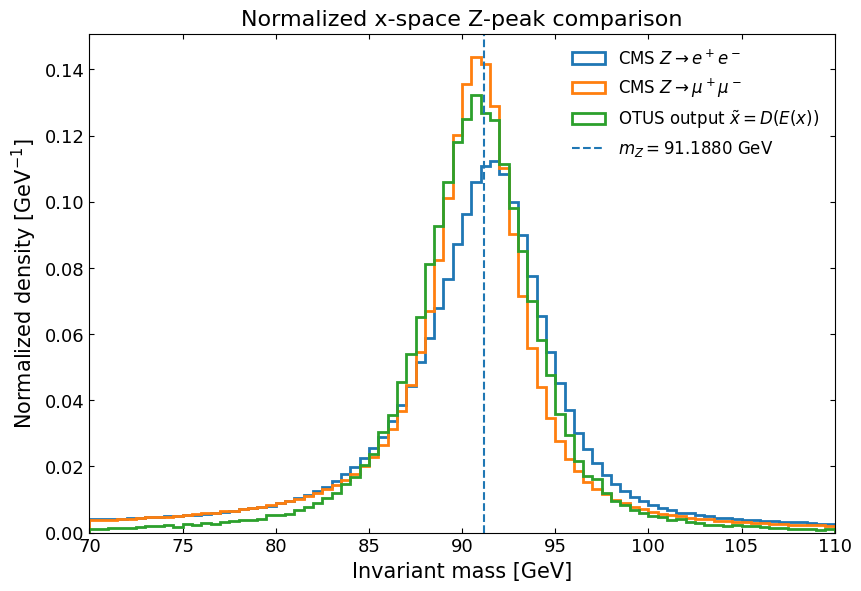

In [38]:
fig, ax = plt.subplots(figsize=(8.5, 5.8), constrained_layout=True)

ax.hist(
    masses_ee_z,
    bins=MASS_BINS,
    histtype="step",
    linewidth=2,
    density=True,
    label=r"CMS $Z\to e^+e^-$",
)

ax.hist(
    masses_mumu_z,
    bins=MASS_BINS,
    histtype="step",
    linewidth=2,
    density=True,
    label=r"CMS $Z\to \mu^+\mu^-$",
)

ax.hist(
    masses_otus_xpred_z_window,
    bins=MASS_BINS,
    histtype="step",
    linewidth=2,
    density=True,
    label=r"OTUS output $\tilde{x}=D(E(x))$",
)

ax.axvline(Z_MASS_GEV, linestyle="--", linewidth=1.5, label=fr"$m_Z={Z_MASS_GEV:.4f}$ GeV")

ax.set_xlabel("Invariant mass [GeV]", fontsize=15)
ax.set_ylabel(r"Normalized density [GeV$^{-1}$]", fontsize=15)
ax.set_title("Normalized x-space Z-peak comparison", fontsize=16)
ax.set_xlim(70, 110)
ax.tick_params(axis="both", labelsize=13, direction="in", top=True, right=True)
ax.legend(frameon=False, fontsize=12)

out = FIG_DIR / "all_three_xspace_zpeaks_normalized.png"
fig.savefig(out, dpi=200)
print(f"Saved to {out}")